<a href="https://colab.research.google.com/github/aniolarolas/quant-research-pricing-credit-risk/blob/task-01-gas-forecasting/notebooks/01_gas_price_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Investigate and analyze price data - Natural Gas Price Forecasting

[Forage](https://www.theforage.com/simulations/jpmorgan/quantitative-research-11oc)

## 1. Problem Understanding

The objective of this task is to estimate the price of natural gas for a given date using historical market data.

This is relevant for pricing natural gas storage contracts. In this type of contract, a client may inject gas into storage when prices are relatively low and withdraw it later when prices are higher.

The economic value of the storage strategy depends on the difference between the buying price, the selling price, and the costs associated with storing the commodity.

Therefore, before pricing the storage contract itself, we first need a model capable of estimating the natural gas price at any given date.

## 2. Commodity Storage Background

Natural gas storage allows market participants to buy gas when prices are low, store it, and sell it later when prices are higher. Therefore, estimating gas prices across dates is a necessary first step before valuing a storage contract.

## 3. Time Series Modelling Framework

Let the historical natural gas price series be represented as:

$$
\{(t_i, P_i)\}_{i=1}^{n}
$$

where:

- $t_i$ is the date of observation,
- $P_i$ is the observed natural gas price.

The goal is to build an estimator:

$$
\hat{P}(t) = f(t)
$$

that returns an estimated natural gas price for a given input date $t$.

As an initial modelling framework, we can think of the price series as containing three possible components:

$$
P(t) = T(t) + S(t) + \varepsilon_t
$$

where:

- $T(t)$ represents a long-term trend,
- $S(t)$ represents recurring seasonal behaviour,
- $\varepsilon_t$ represents residual noise.

This is not assumed to be the true market-generating process. It is only a useful exploratory framework to analyse whether the data contains trend and seasonality.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

BASE_dir = Path("/content/drive/MyDrive/quant_research_jpm_jobsim")

RAW_DATA_dir = BASE_dir / "data" / "raw"
PROCESSED_DATA_dir = BASE_dir / "data" / "processed"
BACKUP_dir = BASE_dir / "colab-backup"

print("Base directory: ", BASE_dir)
print("Raw data directory: ", RAW_DATA_dir)
print("Processed data directory ", PROCESSED_DATA_dir)

Base directory:  /content/drive/MyDrive/quant_research_jpm_jobsim
Raw data directory:  /content/drive/MyDrive/quant_research_jpm_jobsim/data/raw
Processed data directory  /content/drive/MyDrive/quant_research_jpm_jobsim/data/processed


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 4. Data Loading


In [4]:
df = pd.read_csv("/content/drive/MyDrive/quant_research_jpm_jobsim/data/raw/task01/Nat_Gas.csv")

In [5]:
df["Dates"] = pd.to_datetime(df["Dates"], format="%m/%d/%y")

df = df.sort_values("Dates")

In [6]:
df.head()
df.tail()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Dates   48 non-null     datetime64[ns]
 1   Prices  48 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 900.0 bytes


## 5. Exploratory Data Analysis


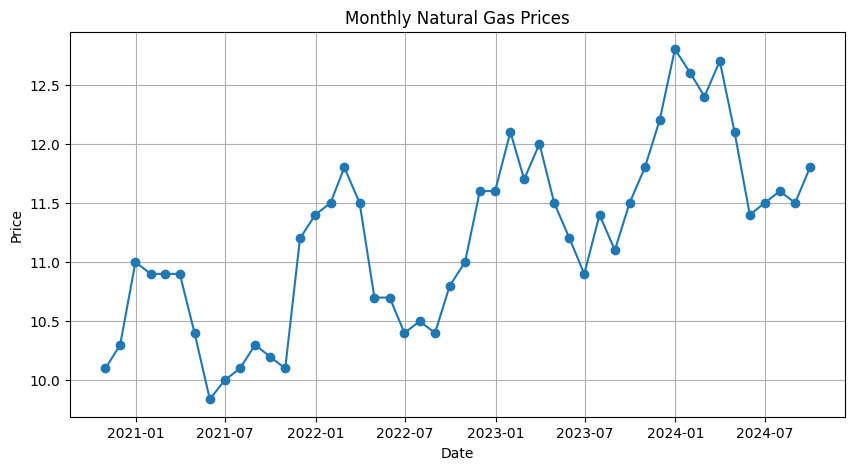

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(df["Dates"], df["Prices"], marker="o")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Monthly Natural Gas Prices")
plt.grid(True)
plt.show()

The series shows a clear upward long-term trend. In addition, the price appears to follow a seasonal annual pattern: prices tend to increase during the winter months and decrease during the warmer months. This suggests that both trend and seasonality should be considered in the price estimation model.
**Let's quantify this pattern!**

### Time Index

To capture the time trend in the series, we create a variable called `time_index`:

$$
t = 0,1,2,\dots,n-1
$$

Each value represents one monthly step in the dataset. This allows us to use time as a numerical input in the model, which is more convenient than working directly with raw dates.

In [8]:
df["year"] = df["Dates"].dt.year
df["month"] = df["Dates"].dt.month
df["month_name"] = df["Dates"].dt.month_name()
df["time_index"] = np.arange(len(df))

df.head()

,Dates,Prices,year,month,month_name,time_index
0,2020-10-31,10.1,2020,10,October,0
1,2020-11-30,10.3,2020,11,November,1
2,2020-12-31,11.0,2020,12,December,2
3,2021-01-31,10.9,2021,1,January,3
4,2021-02-28,10.9,2021,2,February,4


## 6. Trend and Seasonality Analysis


In [9]:
monthly_avg = df.groupby("month")["Prices"].mean()
monthly_avg

,Prices
month,
1,11.775
2,11.700
3,11.775
4,11.175
5,10.785
6,10.700
7,10.900
8,10.825
9,11.075


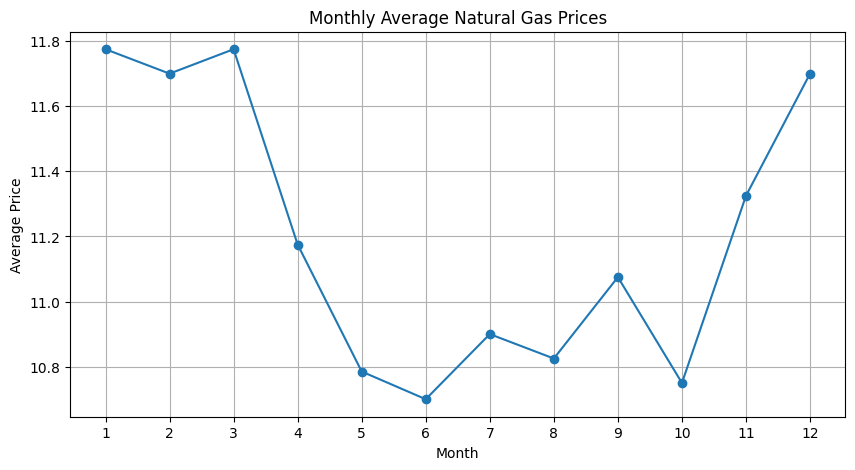

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.title("Monthly Average Natural Gas Prices")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [11]:
pivot_df = df.pivot(index="month", columns="year", values="Prices")
pivot_df

year,2020,2021,2022,2023,2024
month,,,,,
1,NaN,10.90,11.5,12.1,12.6
2,NaN,10.90,11.8,11.7,12.4
3,NaN,10.90,11.5,12.0,12.7
4,NaN,10.40,10.7,11.5,12.1
5,NaN,9.84,10.7,11.2,11.4
6,NaN,10.00,10.4,10.9,11.5
7,NaN,10.10,10.5,11.4,11.6
8,NaN,10.30,10.4,11.1,11.5
9,NaN,10.20,10.8,11.5,11.8


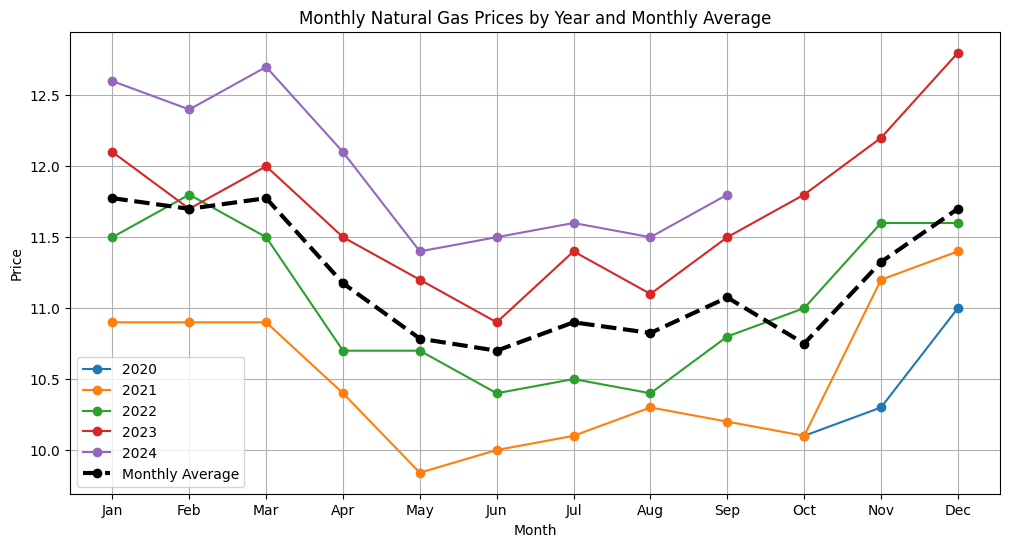

In [12]:
plt.figure(figsize=(12, 6))

for year in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[year], marker="o", label=str(year))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o",
    linewidth=3,
    color="black",
    linestyle="--",
    label="Monthly Average",
)

plt.xlabel("Month")
plt.ylabel("Price")
plt.title("Monthly Natural Gas Prices by Year and Monthly Average")
plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.legend()
plt.grid(True)
plt.show()

### Seasonality Interpretation

The seasonal comparison suggests that natural gas prices tend to be higher during the winter months and the months closest to winter. This behaviour is economically reasonable because natural gas demand typically increases during colder periods, mainly due to heating needs.

In contrast, prices tend to be lower during the warmer months, when heating demand decreases. This supports the idea that natural gas prices are affected by seasonal demand patterns.

Therefore, the observed seasonality is clear enough to be incorporated into the price estimation model. A model based only on a long-term trend would ignore an important part of the price behaviour, while a model that includes both trend and monthly seasonality should provide more realistic estimates.

## 7. Modelling Strategy

The exploratory analysis suggests that the natural gas price series contains two main components:

- a long-term upward trend,
- a recurring annual seasonal pattern.

Therefore, the model should be able to represent both the general evolution of prices over time and the within-year seasonal fluctuations.

A purely linear model would capture the upward trend, but it would ignore the repeated annual pattern. On the other hand, a very complex model would be difficult to justify given the limited size of the dataset, which contains only 48 monthly observations.

For this reason, we use a simple and interpretable regression model with:

- `time_index` to capture the long-term trend,
- sine and cosine terms to capture annual seasonality.

This gives the model enough flexibility to estimate prices between observed monthly data points and extrapolate the pattern one year into the future, while remaining transparent and easy to interpret.

### Trend and Seasonal Regression

The model is defined as:

$$
\hat{P}(t) =
\beta_0
+ \beta_1 t
+ \alpha \sin\left(\frac{2\pi t}{12}\right)
+ \gamma \cos\left(\frac{2\pi t}{12}\right)
$$

where:

- $\hat{P}(t)$ is the estimated natural gas price,
- $t$ is the monthly time index,
- $\beta_0$ is the baseline price level,
- $\beta_1$ captures the long-term trend,
- the sine and cosine terms capture a repeating annual cycle,
- $\alpha$ and $\gamma$ control the size and timing of the seasonal effect.

The term $\frac{2\pi}{12}$ is used because the seasonal pattern is assumed to repeat every 12 months. Using both sine and cosine allows the model to represent an annual cycle with flexible peaks and troughs.

This approach is closely related to signal processing: the price series is treated as a signal composed of a slow-moving trend and a periodic seasonal component.

## 8. Model Training


The following features are created to translate the modelling strategy into numerical inputs for the regression model.

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
df["time_index"] = np.arange(len(df))
df["sin_12"] = np.sin(2*np.pi*df["time_index"]/12)
df["cos_12"] = np.cos(2*np.pi*df["time_index"]/12)

df[["time_index", "sin_12", "cos_12"]].head(13)

,time_index,sin_12,cos_12
0,0,0.000000e+00,1.000000e+00
1,1,5.000000e-01,8.660254e-01
2,2,8.660254e-01,5.000000e-01
3,3,1.000000e+00,6.123234e-17
4,4,8.660254e-01,-5.000000e-01
5,5,5.000000e-01,-8.660254e-01
6,6,1.224647e-16,-1.000000e+00
7,7,-5.000000e-01,-8.660254e-01
8,8,-8.660254e-01,-5.000000e-01
9,9,-1.000000e+00,-1.836970e-16


In [15]:
X = df[["time_index", "sin_12", "cos_12"]]
y = df["Prices"]

In [16]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [17]:
coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
})

print("Intercept:", model.intercept_)
coefficients

Intercept: 10.134915285898744


,feature,coefficient
0,time_index,0.045624
1,sin_12,0.690071
2,cos_12,-0.037887


In [18]:
df["predicted_price"] = model.predict(X)

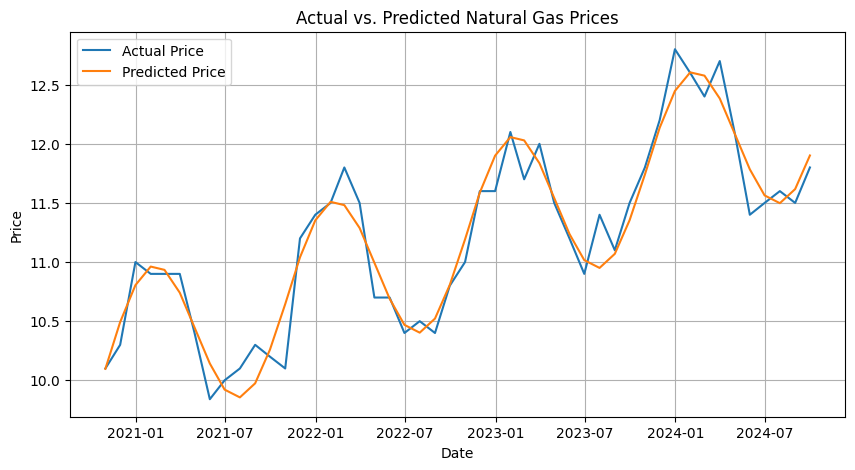

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(df["Dates"], df["Prices"], label="Actual Price")
plt.plot(df["Dates"], df["predicted_price"], label="Predicted Price")

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Actual vs. Predicted Natural Gas Prices")
plt.legend()
plt.grid(True)
plt.show()

The predicted price series follows the main behaviour of the actual data reasonably well. The model captures both the upward trend and the annual seasonal pattern. Some deviations remain, especially around local peaks and troughs, but this is expected because the model is intentionally simple and does not account for short-term market shocks or irregular price movements.

## 9. Model Evaluation

### Error

In [20]:
e = df["Prices"] - df["predicted_price"]

e.head()

,0
0,0.002971
1,-0.192764
2,0.195160
3,-0.061859
4,-0.033975


### Mean Absolute Error

In [21]:
MAE = 1/len(e) * np.sum(np.abs(e))
print("Mean Absolute Error:", MAE)

Mean Absolute Error: 0.1501798052567352


### $R^2$

In [22]:
from sklearn.metrics import r2_score

In [23]:
R2 = r2_score(df["Prices"], df["predicted_price"])

print("R²:", R2)

R²: 0.9290439244562244


The model achieves an R² of 0.929 on the historical dataset, meaning that it explains approximately 92.9% of the observed price variation. This suggests that the combination of a linear trend and annual seasonal terms provides a good in-sample fit. However, this metric should be interpreted carefully because it is evaluated on the same data used to fit the model.

### Root Mean Squared Error

In [24]:
RMSE = np.sqrt(np.mean(e ** 2))
print("Root Mean Squared Error:", RMSE)

Root Mean Squared Error: 0.19977147211302201


In [25]:
metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R²"],
    "value": [MAE, RMSE, R2]
})

metrics

,metric,value
0,MAE,0.150180
1,RMSE,0.199771
2,R²,0.929044


The model achieves a high R² and relatively low error metrics. This suggests that the combination of a linear trend and annual seasonal terms provides a good in-sample approximation of the historical price series. However, the evaluation is performed on the same data used to fit the model, so the results should be interpreted as evidence of historical fit rather than guaranteed future predictive accuracy.

## 10. Final Price Estimation Function

### Manual Transformation Example

To allow the function to estimate prices for any day, the input date is converted into a decimal monthly time index. The value `30.4375` is used as the average number of days per month, calculated as:

$$
\frac{365.25}{12} = 30.4375
$$

In [29]:
input_date = "2023-05-01"
input_date = pd.to_datetime(input_date)
first_date = df["Dates"].min()

t = (input_date - first_date).days / 30.4375
t

29.963039014373717

In [30]:
sin_12 = np.sin(2*np.pi*t/12)
cos_12 = np.cos(2*np.pi*t/12)

print("sin_12:", sin_12)
print("cos_12:", cos_12)

sin_12: 0.019351518818325447
cos_12: -0.9998127418269003


In [31]:
input_features = pd.DataFrame({
    "time_index": [t],
    "sin_12": [sin_12],
    "cos_12": [cos_12]
})

input_features

,time_index,sin_12,cos_12
0,29.963039,0.019352,-0.999813


In [32]:
estimated_price = model.predict(input_features)[0]
print("Estimated price:", estimated_price)

Estimated price: 11.553187477516877


### Final Estimation Function

### Date-to-Model Input Transformation

The trained model does not take calendar dates directly as input. Instead, any input date must first be converted into the same numerical features used during training:

- `time_index`,
- `sin_12`,
- `cos_12`.

To estimate prices for any day, the input date is converted into a decimal monthly time index using the average number of days per month:

$$
\frac{365.25}{12} = 30.4375
$$

The function is restricted to the historical period and approximately one additional year into the future, following the task requirements.

The model is restricted to dates within the historical period and approximately one additional year into the future. Since the dataset contains around 48 monthly observations and the task asks for a one-year extrapolation, the valid range is limited to approximately 60 monthly time steps.

In [62]:
def estimate_gas_price(input_date):
  input_date = pd.to_datetime(input_date)
  first_date = df["Dates"].min()

  t = (input_date - first_date).days / 30.4375

  if (0 <= t <= 60):
    sin_12 = np.sin(2*np.pi*t/12)
    cos_12 = np.cos(2*np.pi*t/12)

    input_features = pd.DataFrame({
       "time_index": [t],
        "sin_12": [sin_12],
       "cos_12": [cos_12]
    })

    estimated_price = model.predict(input_features)[0]

    return estimated_price
  else:
    return "Date out of range"


In [63]:
print("Historical date:", estimate_gas_price("2023-05-01"))
print("Last historical period:", estimate_gas_price("2024-09-30"))
print("Future date:", estimate_gas_price("2025-03-15"))
print("OOR date:", estimate_gas_price("2026-03-15"))

Historical date: 11.553187477516877
Last historical period: 11.894980177241848
Future date: 13.057297418874754
OOR date: Date out of range


In [66]:
future_dates = pd.date_range(start="2024-10-01", end="2025-10-31", freq="MS")
future_dates

DatetimeIndex(['2024-10-01', '2024-11-01', '2024-12-01', '2025-01-01',
               '2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01',
               '2025-06-01', '2025-07-01', '2025-08-01', '2025-09-01',
               '2025-10-01'],
              dtype='datetime64[ns]', freq='MS')

In [67]:
future_predictions = [estimate_gas_price(date) for date in future_dates]
future_predictions

[np.float64(11.90642663732937),
 np.float64(12.300363913618368),
 np.float64(12.689519246800945),
 np.float64(13.003689803846026),
 np.float64(13.155157794715839),
 np.float64(13.126787434139793),
 np.float64(12.93242622936587),
 np.float64(12.642987229837683),
 np.float64(12.332589161851624),
 np.float64(12.113714706319007),
 np.float64(12.045475118162287),
 np.float64(12.168884020639428),
 np.float64(12.451044612384717)]

In [69]:
forecast_df = pd.DataFrame({
    "Dates": future_dates,
    "Estimated Price": future_predictions
})

forecast_df

,Dates,Estimated Price
0,2024-10-01,11.906427
1,2024-11-01,12.300364
2,2024-12-01,12.689519
3,2025-01-01,13.003690
4,2025-02-01,13.155158
5,2025-03-01,13.126787
6,2025-04-01,12.932426
7,2025-05-01,12.642987
8,2025-06-01,12.332589
9,2025-07-01,12.113715


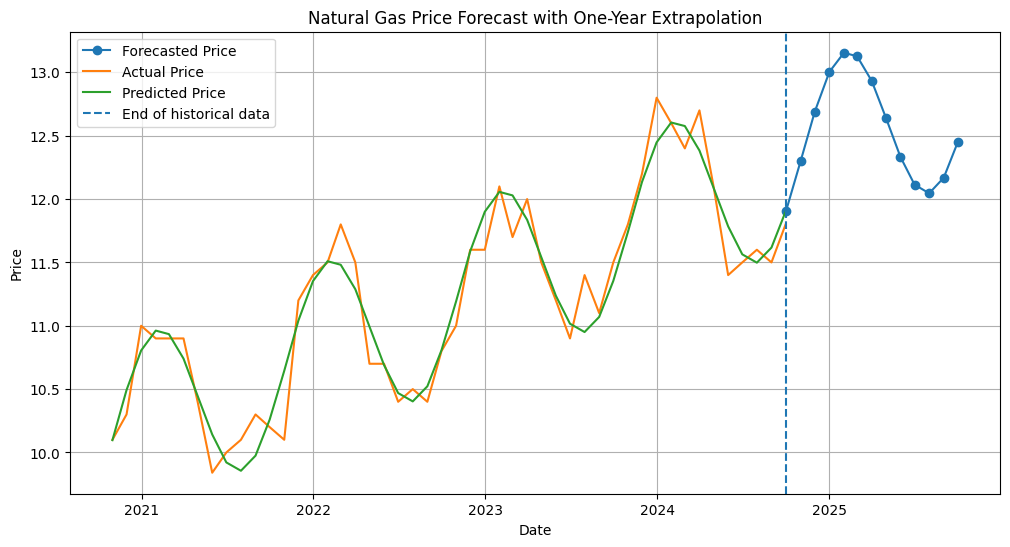

In [74]:
plt.figure(figsize=(12, 6))

plt.plot(forecast_df["Dates"], forecast_df["Estimated Price"], marker="o", label="Forecasted Price")
plt.plot(df["Dates"], df["Prices"], label="Actual Price")
plt.plot(df["Dates"], df["predicted_price"], label="Predicted Price")

plt.axvline(
    df["Dates"].max(),
    linestyle="--",
    label="End of historical data"
)

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Natural Gas Price Forecast with One-Year Extrapolation")
plt.legend()
plt.grid(True)

plt.show()

The final chart shows the historical natural gas prices, the model fit over the observed period, and the one-year extrapolated forecast. The forecast continues the upward trend and seasonal annual pattern learned from the historical data. Since the forecasted section is beyond the available observations, it should be interpreted as an indicative estimate rather than a precise market prediction.

## 11. Limitations and Next Steps

This model provides a simple and interpretable estimate of natural gas prices using a linear trend and annual seasonality. The results show that this approach captures the main structure of the historical data reasonably well and provides a useful indicative price estimate for dates within the historical range and up to one year into the future.

However, the model has several limitations. First, it is based only on monthly price observations, so it does not capture daily market movements or short-term volatility. Although the function can return an estimate for any date, the underlying data is monthly, meaning that intra-month estimates should be interpreted as approximations.

Second, the model only uses time-based features: a linear trend and annual seasonal terms. It does not include external market drivers such as weather conditions, storage inventory levels, supply disruptions, geopolitical events, changes in demand, or movements in the futures curve. These factors can have a significant impact on natural gas prices, especially during periods of market stress.

Third, the one-year extrapolation assumes that the historical trend and seasonal pattern continue into the future. This is a useful simplifying assumption for an indicative estimate, but it should not be interpreted as a precise market forecast.

Future improvements could include using a larger historical dataset, incorporating daily price data, adding external explanatory variables such as temperature and storage inventory levels, and testing more advanced time series models. These additions could improve the robustness of the forecast and make the model more suitable for real trading or pricing decisions.

Overall, the model is appropriate for the objective of this task: producing a clear, interpretable and indicative estimate of natural gas prices for use in the preliminary pricing of storage contracts.